In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [6]:
# ─────────────────────────────────────────
# CELL 2: Load Datasets (Correct Paths)
# ─────────────────────────────────────────

brent  = pd.read_csv('/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/Brent Oil (1).csv')
gold   = pd.read_csv('/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/Gold 100years (1).csv')
silver = pd.read_csv('/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/silver 100 years (1).csv')
swift  = pd.read_csv('/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/swift_currency_tracker_all_reports.csv')

print('✅ All datasets loaded!')
print(f'Brent Oil:  {brent.shape}')
print(f'Gold:       {gold.shape}')
print(f'Silver:     {silver.shape}')
print(f'SWIFT:      {swift.shape}')

✅ All datasets loaded!
Brent Oil:  (963, 2)
Gold:       (1336, 2)
Silver:     (1336, 2)
SWIFT:      (330, 10)


In [7]:
import os

# Find your uploaded files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/silver 100 years (1).csv
/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/swift_currency_tracker_all_reports.csv
/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/Brent Oil (1).csv
/kaggle/input/datasets/sandeshhp5400/data-science-and-buisness-project/Gold 100years (1).csv


In [8]:
def clean_commodity(df, name):
    df = df.copy()
    df.columns = ['Date', 'Value']
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df.dropna(inplace=True)
    df.sort_values('Date', inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['Asset'] = name
    print(f'{name}: {len(df)} rows | {df["Date"].min().year} - {df["Date"].max().year}')
    return df

brent_c  = clean_commodity(brent,  'Brent Oil')
gold_c   = clean_commodity(gold,   'Gold')
silver_c = clean_commodity(silver, 'Silver')

# Clean SWIFT
swift_c = swift.copy()
swift_c['value'] = pd.to_numeric(swift_c['value'], errors='coerce')
swift_c.dropna(subset=['value'], inplace=True)

print('\n✅ Data cleaning complete!')

Brent Oil: 963 rows | 1946 - 2026
Gold: 1336 rows | 1915 - 2026
Silver: 1336 rows | 1915 - 2026

✅ Data cleaning complete!


In [9]:
print('='*50)
print('BRENT OIL - Summary Statistics')
print('='*50)
print(brent_c['Value'].describe())

print('\n' + '='*50)
print('GOLD - Summary Statistics')
print('='*50)
print(gold_c['Value'].describe())

print('\n' + '='*50)
print('SILVER - Summary Statistics')
print('='*50)
print(silver_c['Value'].describe())

print('\n' + '='*50)
print('SWIFT Currency - Metrics Available')
print('='*50)
print(swift_c['metric'].value_counts().head(10))

BRENT OIL - Summary Statistics
count    963.000000
mean      62.709470
std       35.964228
min       21.110000
25%       33.360000
50%       50.120000
75%       82.380000
max      211.210000
Name: Value, dtype: float64

GOLD - Summary Statistics
count    1336.000000
mean      397.551394
std       651.394525
min        19.250000
25%        35.000000
50%        40.950000
75%       401.075000
max      5277.890000
Name: Value, dtype: float64

SILVER - Summary Statistics
count    1336.000000
mean        6.421755
std         9.896696
min         0.280000
25%         0.720000
50%         1.830000
75%         6.762500
max       113.952800
Name: Value, dtype: float64

SWIFT Currency - Metrics Available
metric
Global Payment Share                         80
International Payment Share (ex-Eurozone)    80
Offshore RMB by Economy                      60
Trade Finance Share                          40
FX Spot Economies (RMB)                      24
RMB MoM Payment Growth                        2
Al

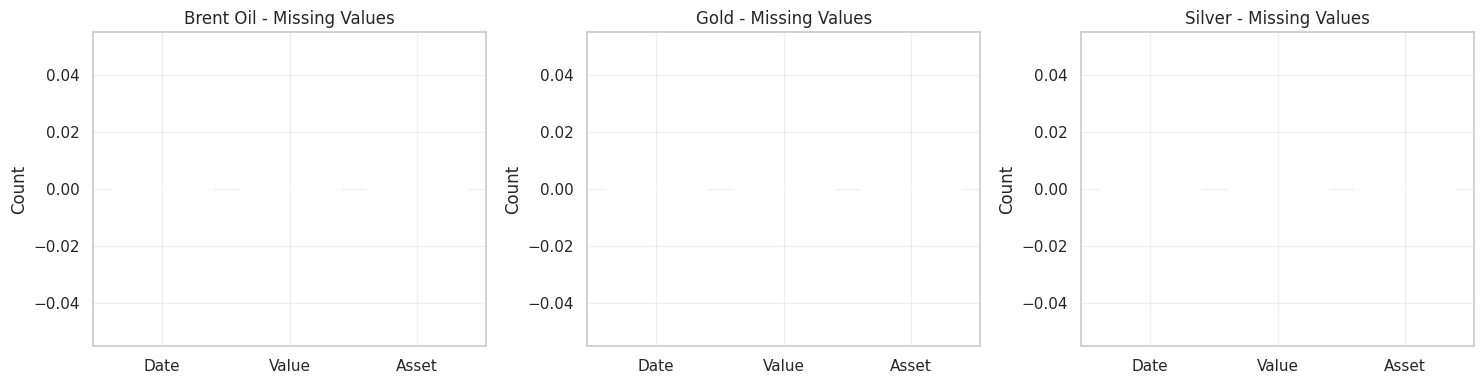

✅ No missing values detected in cleaned data!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [('Brent Oil', brent_c), ('Gold', gold_c), ('Silver', silver_c)]

for ax, (name, df) in zip(axes, datasets):
    missing = df.isnull().sum()
    ax.bar(missing.index, missing.values, color='steelblue')
    ax.set_title(f'{name} - Missing Values')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ No missing values detected in cleaned data!')

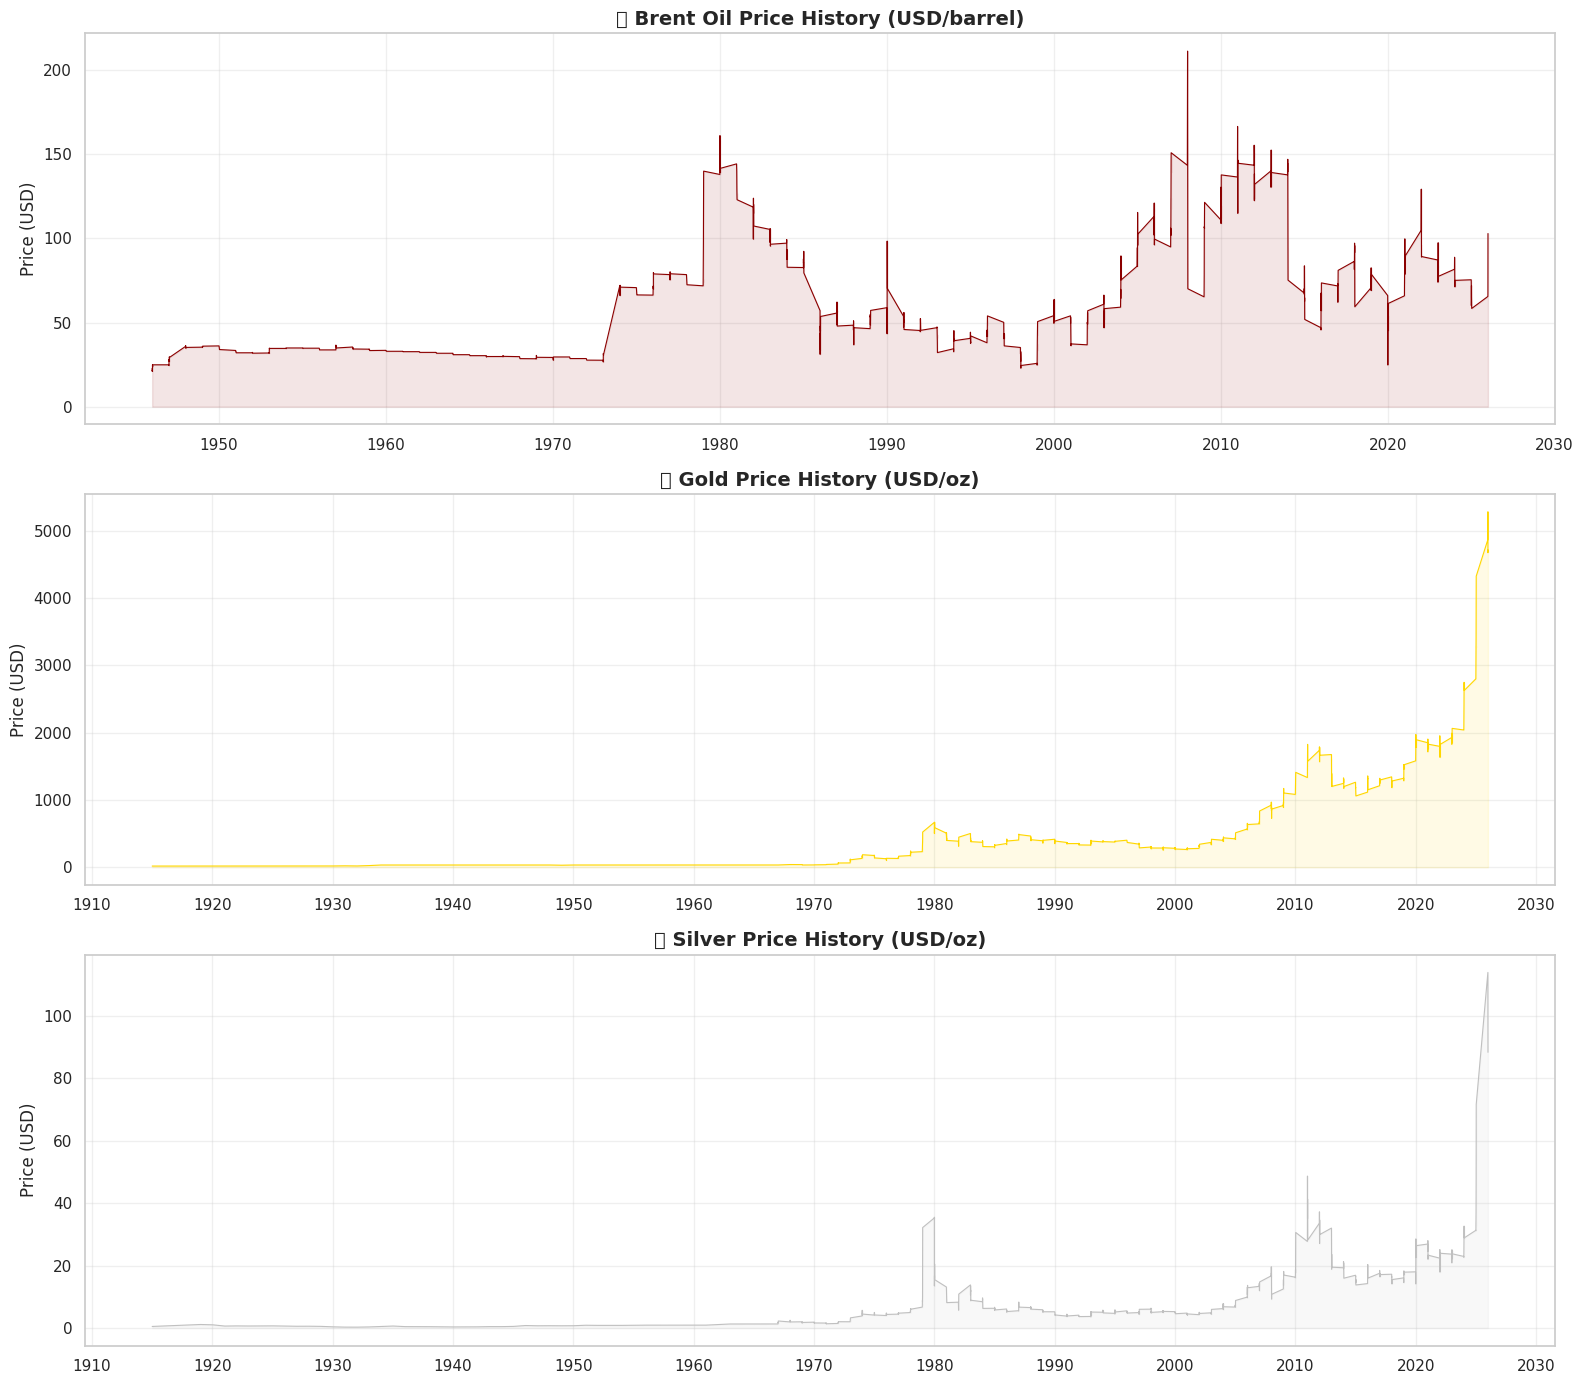

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Brent Oil
axes[0].plot(brent_c['Date'], brent_c['Value'], color='#8B0000', linewidth=0.8)
axes[0].set_title('🛢️ Brent Oil Price History (USD/barrel)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].fill_between(brent_c['Date'], brent_c['Value'], alpha=0.1, color='#8B0000')

# Gold
axes[1].plot(gold_c['Date'], gold_c['Value'], color='#FFD700', linewidth=0.8)
axes[1].set_title('🥇 Gold Price History (USD/oz)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].fill_between(gold_c['Date'], gold_c['Value'], alpha=0.1, color='#FFD700')

# Silver
axes[2].plot(silver_c['Date'], silver_c['Value'], color='#C0C0C0', linewidth=0.8)
axes[2].set_title('🥈 Silver Price History (USD/oz)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Price (USD)')
axes[2].fill_between(silver_c['Date'], silver_c['Value'], alpha=0.1, color='#C0C0C0')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(10))

plt.tight_layout()
plt.savefig('price_trends.png', dpi=150, bbox_inches='tight')
plt.show()

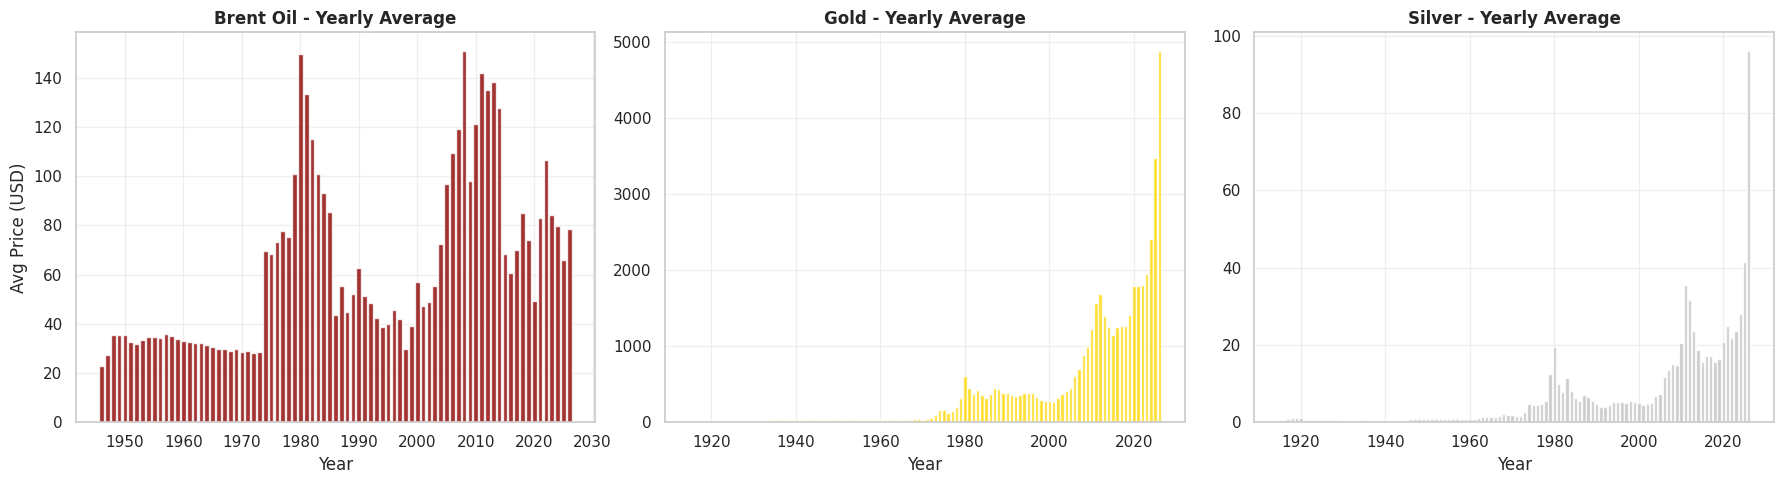

In [12]:
brent_y  = brent_c.groupby(brent_c['Date'].dt.year)['Value'].mean()
gold_y   = gold_c.groupby(gold_c['Date'].dt.year)['Value'].mean()
silver_y = silver_c.groupby(silver_c['Date'].dt.year)['Value'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(brent_y.index, brent_y.values, color='#8B0000', alpha=0.8)
axes[0].set_title('Brent Oil - Yearly Average', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg Price (USD)')

axes[1].bar(gold_y.index, gold_y.values, color='#FFD700', alpha=0.8)
axes[1].set_title('Gold - Yearly Average', fontweight='bold')
axes[1].set_xlabel('Year')

axes[2].bar(silver_y.index, silver_y.values, color='#C0C0C0', alpha=0.8)
axes[2].set_title('Silver - Yearly Average', fontweight='bold')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('yearly_averages.png', dpi=150, bbox_inches='tight')
plt.show()

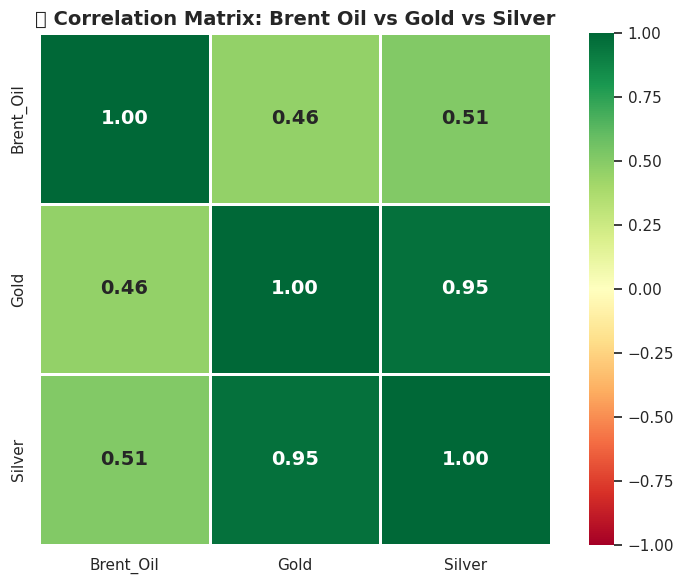

Correlation Values:
           Brent_Oil      Gold    Silver
Brent_Oil   1.000000  0.457676  0.514779
Gold        0.457676  1.000000  0.953756
Silver      0.514779  0.953756  1.000000


In [13]:
brent_y_df  = brent_y.reset_index().rename(columns={'Date': 'Year', 'Value': 'Brent_Oil'})
gold_y_df   = gold_y.reset_index().rename(columns={'Date': 'Year', 'Value': 'Gold'})
silver_y_df = silver_y.reset_index().rename(columns={'Date': 'Year', 'Value': 'Silver'})

merged = brent_y_df.merge(gold_y_df, on='Year').merge(silver_y_df, on='Year')

corr_matrix = merged[['Brent_Oil', 'Gold', 'Silver']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=1,
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('📊 Correlation Matrix: Brent Oil vs Gold vs Silver', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation Values:')
print(corr_matrix)

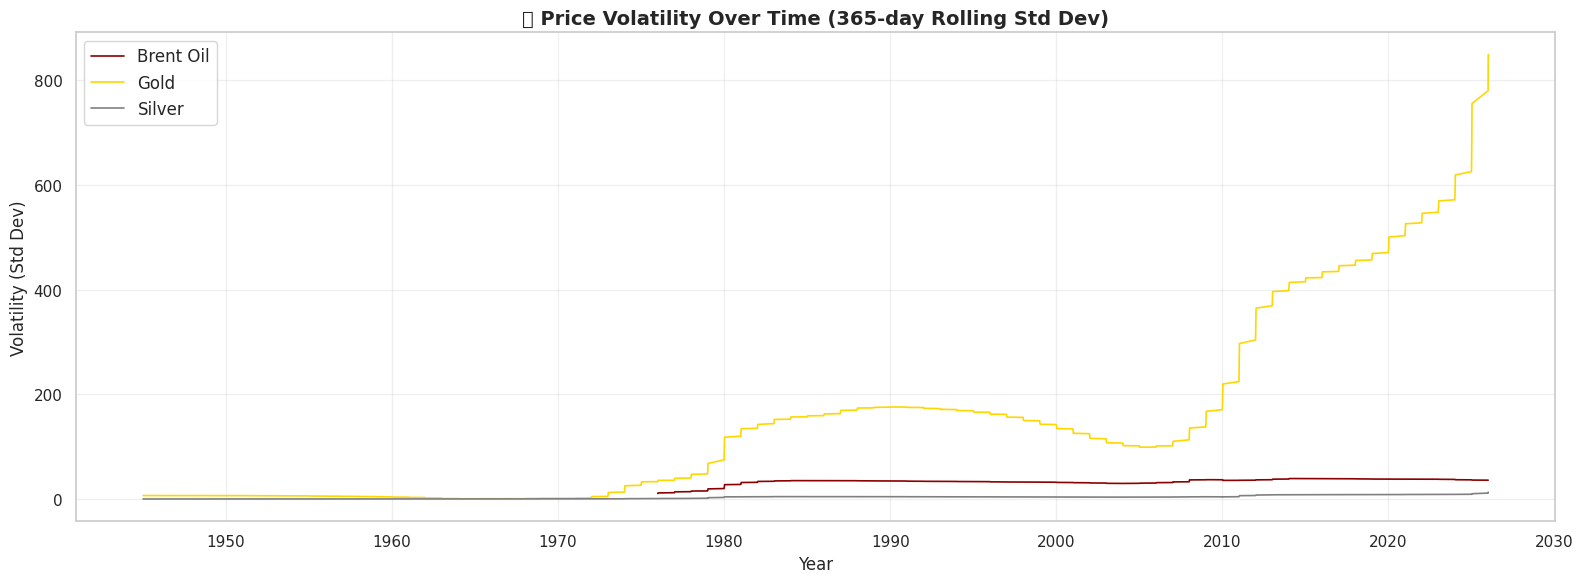

In [14]:
window = 365  # 1-year rolling window

brent_c['Volatility']  = brent_c['Value'].rolling(window).std()
gold_c['Volatility']   = gold_c['Value'].rolling(window).std()
silver_c['Volatility'] = silver_c['Value'].rolling(window).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(brent_c['Date'],  brent_c['Volatility'],  label='Brent Oil',  color='#8B0000', linewidth=1.2)
ax.plot(gold_c['Date'],   gold_c['Volatility'],   label='Gold',       color='#FFD700', linewidth=1.2)
ax.plot(silver_c['Date'], silver_c['Volatility'], label='Silver',     color='#808080', linewidth=1.2)
ax.set_title('📈 Price Volatility Over Time (365-day Rolling Std Dev)', fontsize=14, fontweight='bold')
ax.set_ylabel('Volatility (Std Dev)')
ax.set_xlabel('Year')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('volatility.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
payments = swift_c[swift_c['metric'] == 'Payments']

if len(payments) > 0:
    latest = payments.sort_values('data_month').groupby('currency_or_economy').last()
    top10 = latest.nlargest(10, 'value')

    plt.figure(figsize=(12, 6))
    colors = ['#003087' if c != 'CNY' else '#DE2910' for c in top10.index]
    bars = plt.bar(top10.index, top10['value'], color=colors, alpha=0.85, edgecolor='white')
    plt.title('💱 Top 10 Currencies - SWIFT Payment Share (%)', fontsize=14, fontweight='bold')
    plt.ylabel('Payment Share (%)')
    plt.xlabel('Currency')
    for bar, val in zip(bars, top10['value']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('swift_payments.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Checking available metrics...')
    print(swift_c['metric'].unique())

Checking available metrics...
['Global Payment Share' 'International Payment Share (ex-Eurozone)'
 'RMB MoM Payment Growth' 'All Currencies MoM Payment Growth'
 'Offshore RMB by Economy' 'Trade Finance Share' 'FX Spot Economies (RMB)']


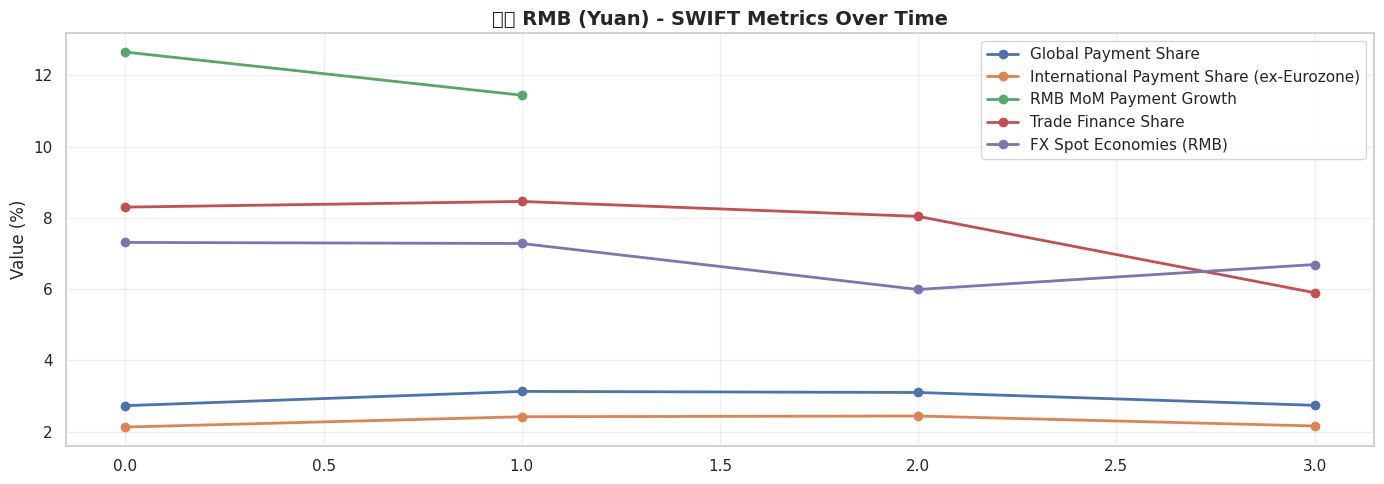

In [16]:
rmb_data = swift_c[swift_c['currency_or_economy'].str.contains('CNY|RMB|Yuan|China', case=False, na=False)]

if len(rmb_data) > 0:
    plt.figure(figsize=(14, 5))
    for metric in rmb_data['metric'].unique():
        subset = rmb_data[rmb_data['metric'] == metric]
        plt.plot(range(len(subset)), subset['value'], marker='o', label=metric, linewidth=2)
    plt.title('🇨🇳 RMB (Yuan) - SWIFT Metrics Over Time', fontsize=14, fontweight='bold')
    plt.ylabel('Value (%)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('rmb_trend.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('RMB data not found, showing all currencies...')
    print(swift_c['currency_or_economy'].unique()[:20])

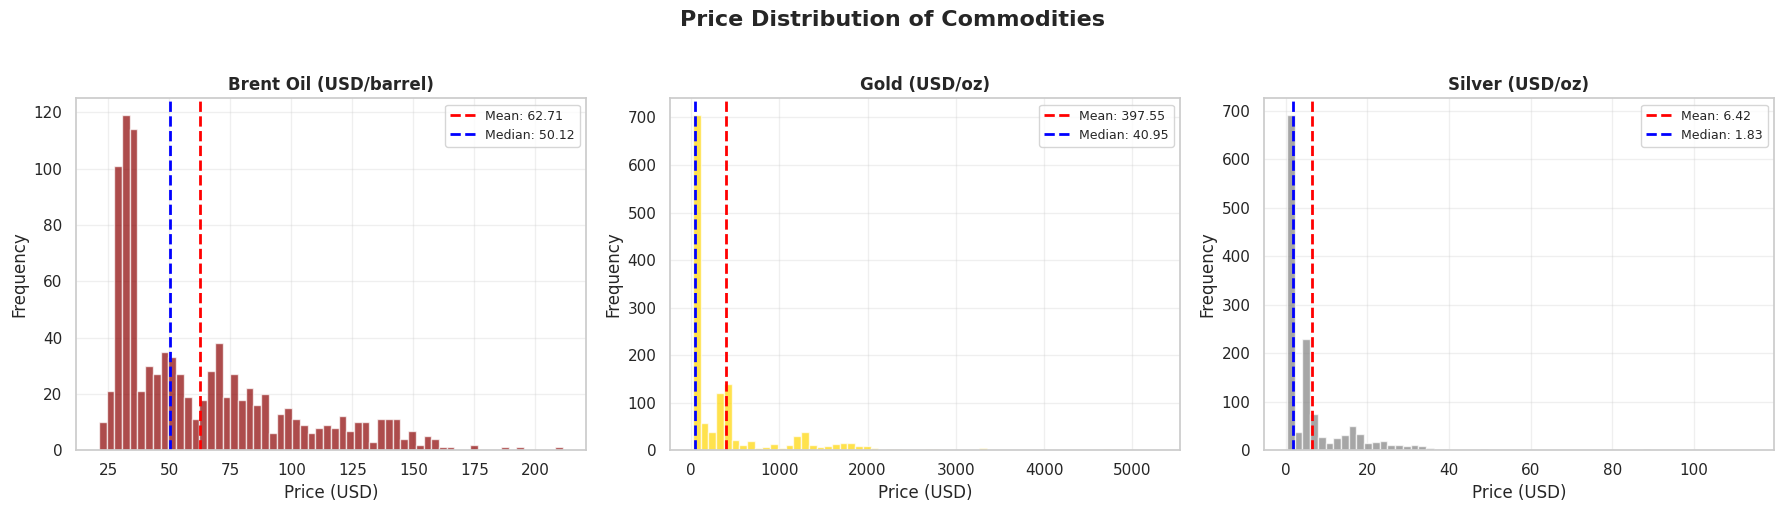

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets_info = [
    (brent_c,  'Brent Oil (USD/barrel)', '#8B0000'),
    (gold_c,   'Gold (USD/oz)',          '#FFD700'),
    (silver_c, 'Silver (USD/oz)',        '#808080')
]

for ax, (df, title, color) in zip(axes, datasets_info):
    ax.hist(df['Value'], bins=60, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(df['Value'].mean(),   color='red',  linestyle='--', linewidth=2, label=f'Mean: {df["Value"].mean():.2f}')
    ax.axvline(df['Value'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df["Value"].median():.2f}')
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_xlabel('Price (USD)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Price Distribution of Commodities', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print('='*60)
print('📊 KEY INSIGHTS SUMMARY')
print('='*60)

print('\n🛢️ BRENT OIL')
print(f'  Period:     {brent_c["Date"].min().year} - {brent_c["Date"].max().year}')
print(f'  Min Price:  ${brent_c["Value"].min():.2f}')
print(f'  Max Price:  ${brent_c["Value"].max():.2f}')
print(f'  Avg Price:  ${brent_c["Value"].mean():.2f}')

print('\n🥇 GOLD')
print(f'  Period:     {gold_c["Date"].min().year} - {gold_c["Date"].max().year}')
print(f'  Min Price:  ${gold_c["Value"].min():.2f}')
print(f'  Max Price:  ${gold_c["Value"].max():.2f}')
print(f'  Avg Price:  ${gold_c["Value"].mean():.2f}')

print('\n🥈 SILVER')
print(f'  Period:     {silver_c["Date"].min().year} - {silver_c["Date"].max().year}')
print(f'  Min Price:  ${silver_c["Value"].min():.2f}')
print(f'  Max Price:  ${silver_c["Value"].max():.2f}')
print(f'  Avg Price:  ${silver_c["Value"].mean():.2f}')

print('\n💱 SWIFT CURRENCY')
print(f'  Total Records: {len(swift_c)}')
print(f'  Currencies:    {swift_c["currency_or_economy"].nunique()}')
print(f'  Metrics:       {swift_c["metric"].nunique()}')

print('\n✅ Analysis Complete!')

📊 KEY INSIGHTS SUMMARY

🛢️ BRENT OIL
  Period:     1946 - 2026
  Min Price:  $21.11
  Max Price:  $211.21
  Avg Price:  $62.71

🥇 GOLD
  Period:     1915 - 2026
  Min Price:  $19.25
  Max Price:  $5277.89
  Avg Price:  $397.55

🥈 SILVER
  Period:     1915 - 2026
  Min Price:  $0.28
  Max Price:  $113.95
  Avg Price:  $6.42

💱 SWIFT CURRENCY
  Total Records: 288
  Currencies:    47
  Metrics:       7

✅ Analysis Complete!
